# This notebook provides a minimal example on how to use SysVar.
# We will create Eigenvariations of our fitting variable based on the charged slow pion corrections in 2 reconstruction channels and for 2 templates in 15 bins

In [8]:
%reload_ext autoreload
%autoreload 2

# Create a pseudo-dataset

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sample_size = 2000
theta =  5.5
momentum_scaler =MinMaxScaler((0.05, 0.4))
momentum_scaler.fit(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1))
toy_df = pd.DataFrame(
    {
        "channel": np.random.randint(0, 2, sample_size), # Assume 4 reco channels,
        "template": np.random.randint(1, 3, sample_size), # Assume 2 templates, 1 = signal and 2 = BKG
        "slow_pi_p": momentum_scaler.transform(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1)).flatten(),
        "slow_pi2_p": momentum_scaler.transform(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1)).flatten()
    }
)

toy_df["slow_pi_mcPDG"] =  np.random.choice([-211, 211], sample_size)
toy_df["slow_pi2_mcPDG"] =  np.random.choice([-211, 211], sample_size)
toy_df["slow_pi_PDG"] =  np.random.choice([-211, 211], sample_size)
toy_df["slow_pi2_PDG"] =  np.random.choice([-211, 211], sample_size)

toy_df.loc[toy_df.template == 1, "fit_variable1"] = np.random.exponential(0.2, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "fit_variable2"] = np.random.normal(2.5, 0.3, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "other_weight"] = np.random.normal(0.3, 0.04, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 2, "fit_variable1"] = np.random.power(1.5, len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "fit_variable2"] = np.random.rayleigh(1.5, size = len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "other_weight"] = np.random.normal(0.8, 0.1, len(toy_df[toy_df.template == 2]))

toy_df = toy_df.query("0 < fit_variable1 < 1")
toy_df = toy_df.query("1 < fit_variable2 < 4")
toy_df = toy_df.query("0.05 < slow_pi_p < 0.4")
toy_df = toy_df.query("0.05 < slow_pi2_p < 0.4")

toy_df["template"].replace(1, "signal", inplace = True)
toy_df["template"].replace(2, "bkg", inplace = True)

toy_df


/tmp/ipykernel_14864/1154680904.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  toy_df["template"].replace(1, "signal", inplace = True)


,channel,template,slow_pi_p,slow_pi2_p,slow_pi_mcPDG,slow_pi2_mcPDG,slow_pi_PDG,slow_pi2_PDG,fit_variable1,fit_variable2,other_weight
0,1,bkg,0.227781,0.137421,-211,-211,-211,211,0.720781,2.539194,0.772213
1,0,bkg,0.094536,0.145306,211,-211,211,211,0.796107,2.364625,0.755369
2,0,signal,0.131615,0.216794,211,-211,-211,-211,0.171314,3.014376,0.358932
3,1,bkg,0.165196,0.149455,211,211,211,-211,0.614946,3.135813,0.728348
4,0,bkg,0.179144,0.109305,211,-211,-211,-211,0.875564,1.334891,0.779574
...,...,...,...,...,...,...,...,...,...,...,...
1995,0,signal,0.134688,0.149316,211,211,-211,211,0.042569,2.659588,0.360758
1996,0,signal,0.050045,0.184129,211,211,-211,-211,0.590344,2.430133,0.242645
1997,1,bkg,0.284660,0.224082,211,-211,211,-211,0.687028,1.266896,0.893683
1998,1,signal,0.159974,0.108031,211,211,211,211,0.305517,2.508847,0.230451


# Now let's add slow pion weights to the dataframe

In [10]:
from sysvar import add_weights_to_dataframe

add_weights_to_dataframe(
    df = toy_df,
    systematic= "charged_slow_pi",
    MC_production= "MC15ri",
    prefix= "slow_pi",
    weightname ="charged_weight",
    #overwrite: False,
    #Nvar: 0
)
toy_df

INFO : add_weights_to_dataframe: 81 :  slow_pi_charged_weight does not exist. Adding it to dataframe


,channel,template,slow_pi_p,slow_pi2_p,slow_pi_mcPDG,slow_pi2_mcPDG,slow_pi_PDG,slow_pi2_PDG,fit_variable1,fit_variable2,other_weight,slow_pi_charged_weight
0,1,bkg,0.227781,0.137421,-211,-211,-211,211,0.720781,2.539194,0.772213,1.000
1,0,bkg,0.094536,0.145306,211,-211,211,211,0.796107,2.364625,0.755369,0.996
2,0,signal,0.131615,0.216794,211,-211,-211,-211,0.171314,3.014376,0.358932,0.990
3,1,bkg,0.165196,0.149455,211,211,211,-211,0.614946,3.135813,0.728348,0.987
4,0,bkg,0.179144,0.109305,211,-211,-211,-211,0.875564,1.334891,0.779574,0.987
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,signal,0.134688,0.149316,211,211,-211,211,0.042569,2.659588,0.360758,0.990
1996,0,signal,0.050045,0.184129,211,211,-211,-211,0.590344,2.430133,0.242645,0.996
1997,1,bkg,0.284660,0.224082,211,-211,211,-211,0.687028,1.266896,0.893683,1.000
1998,1,signal,0.159974,0.108031,211,211,211,211,0.305517,2.508847,0.230451,0.990


If you try again, then SysVar will complain. In order to overwrite an existing weight, set the relevant argument to True

In [4]:
add_weights_to_dataframe(
    df = toy_df,
    systematic= "charged_slow_pi",
    MC_production= "MC15ri",
    prefix= "slow_pi",
    weightname ="charged_weight",
    #overwrite: False
)

Now we create the total weight of the analysis

In [5]:
toy_df["total_weight"] = toy_df[["other_weight", "slow_pi_charged_weight"]].product(axis = 1)

# Let's plot what we have

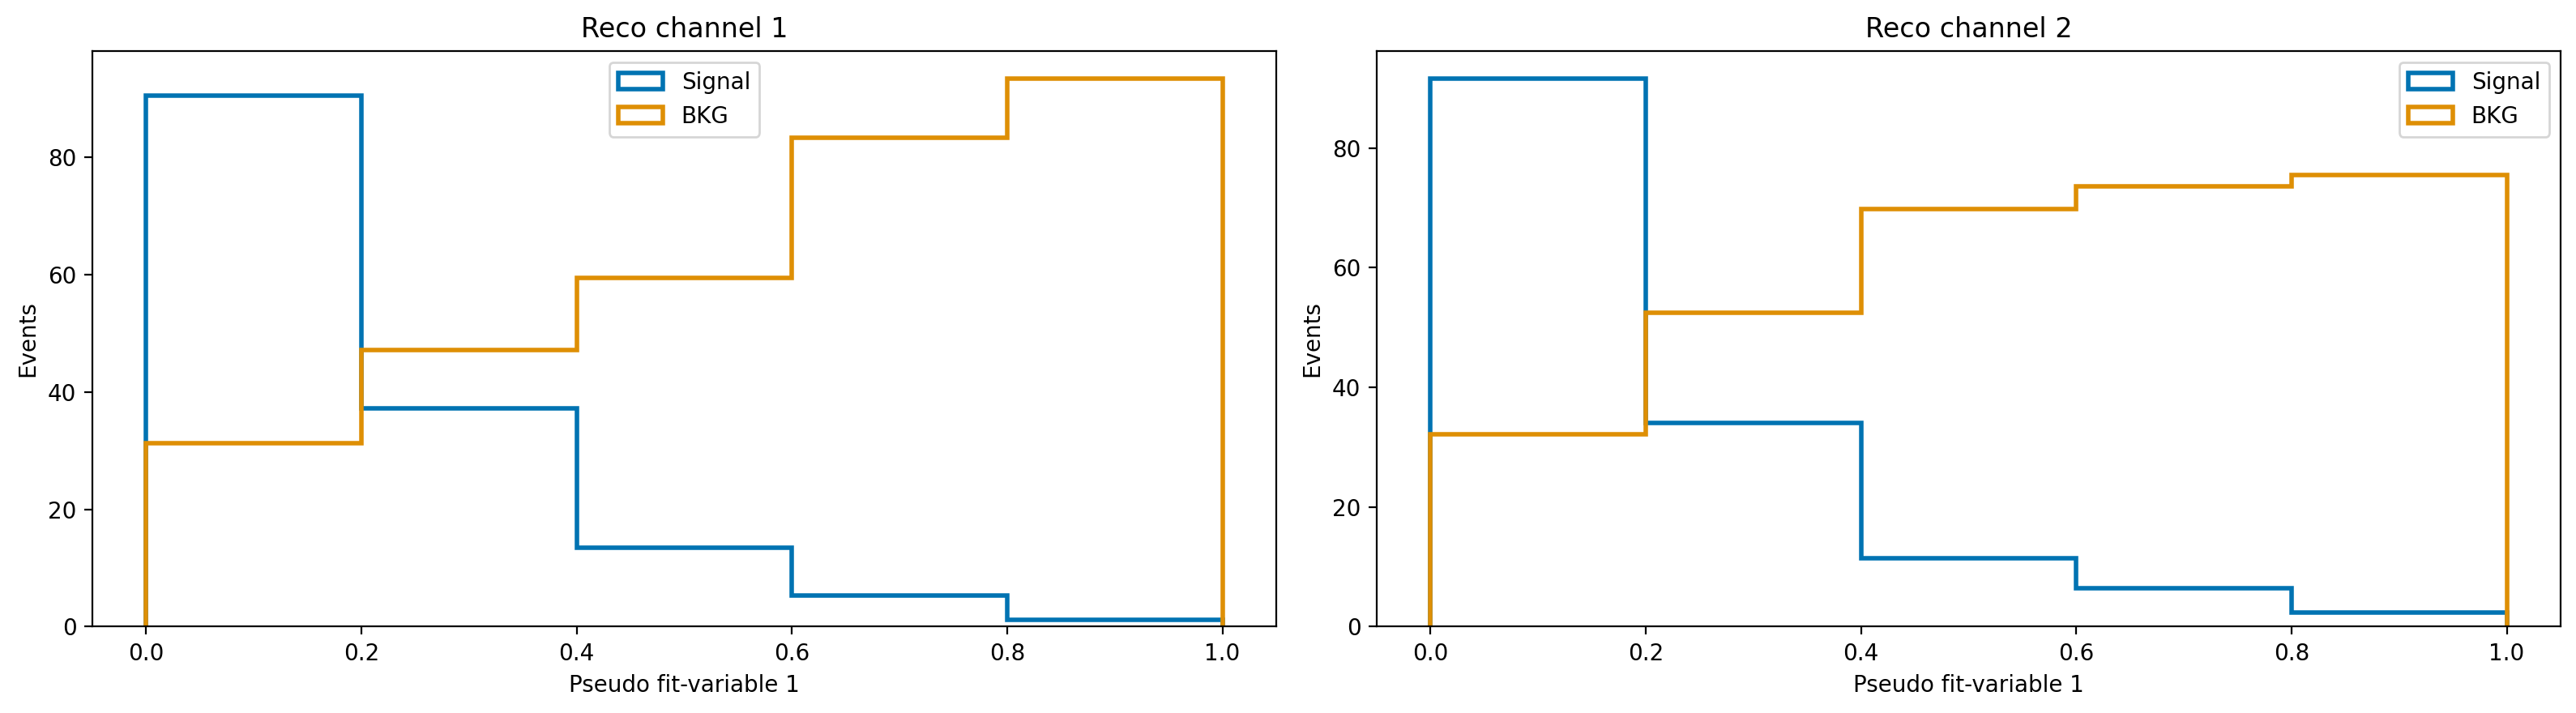

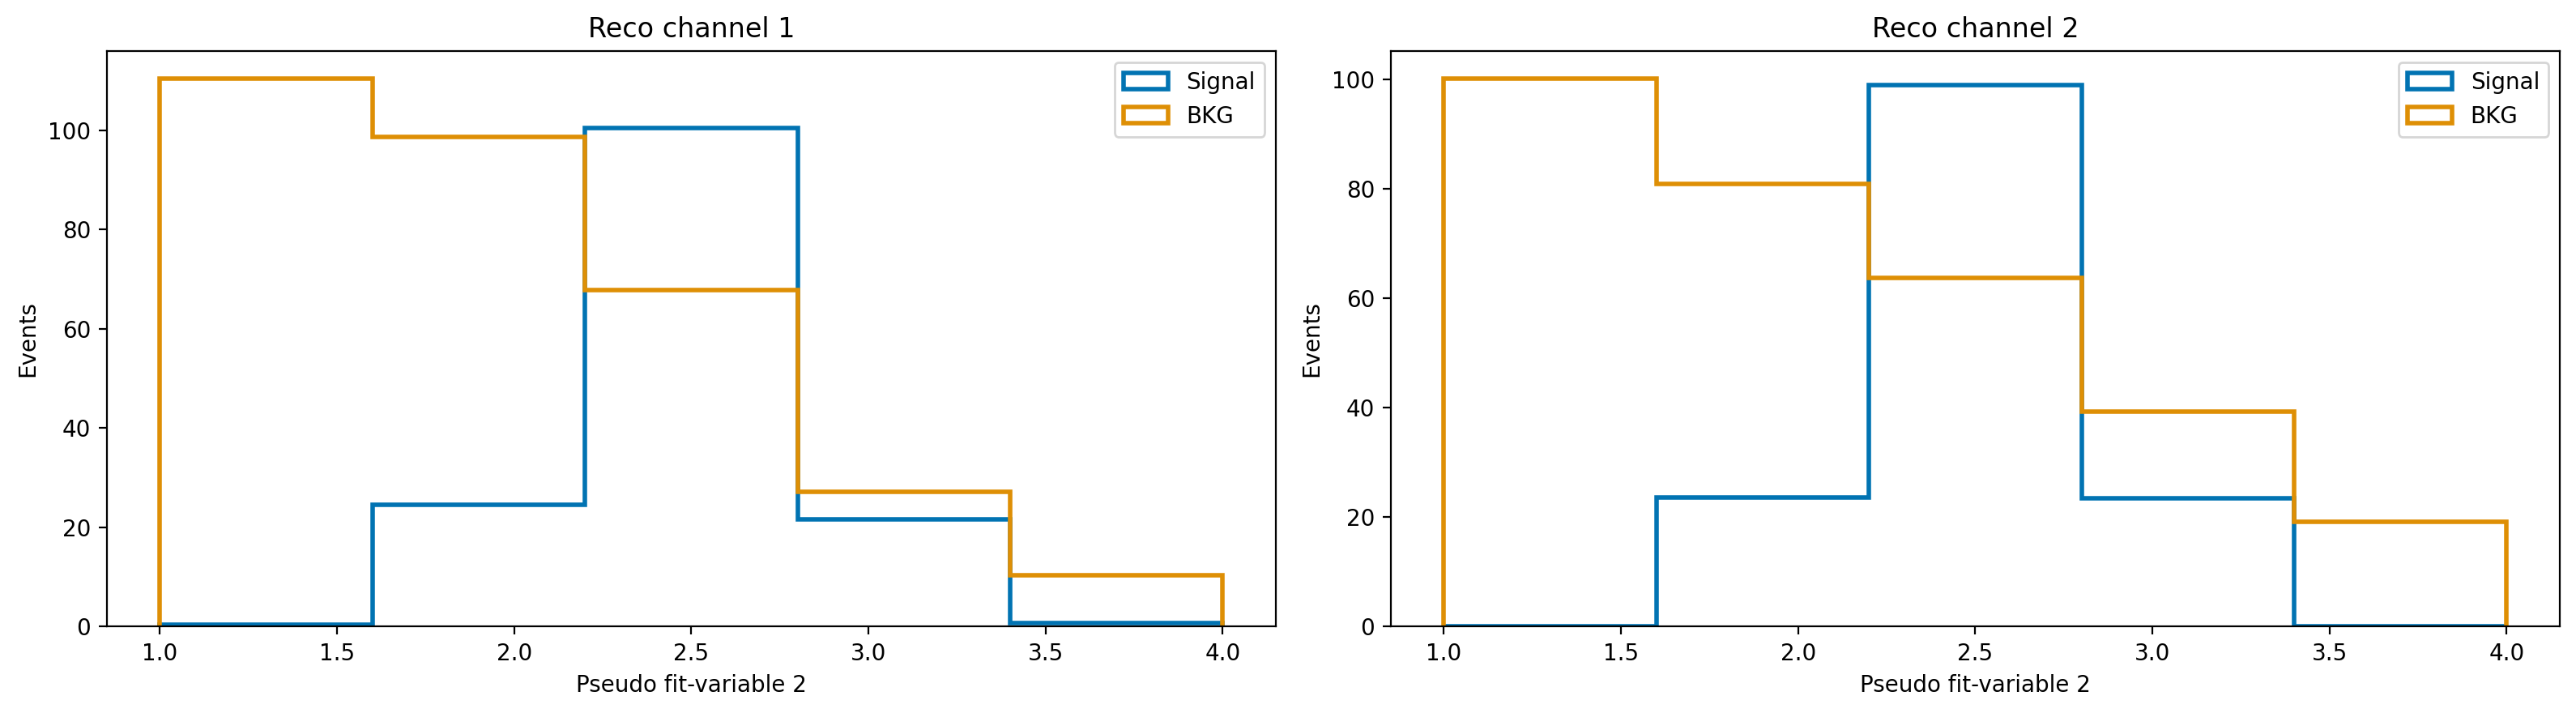

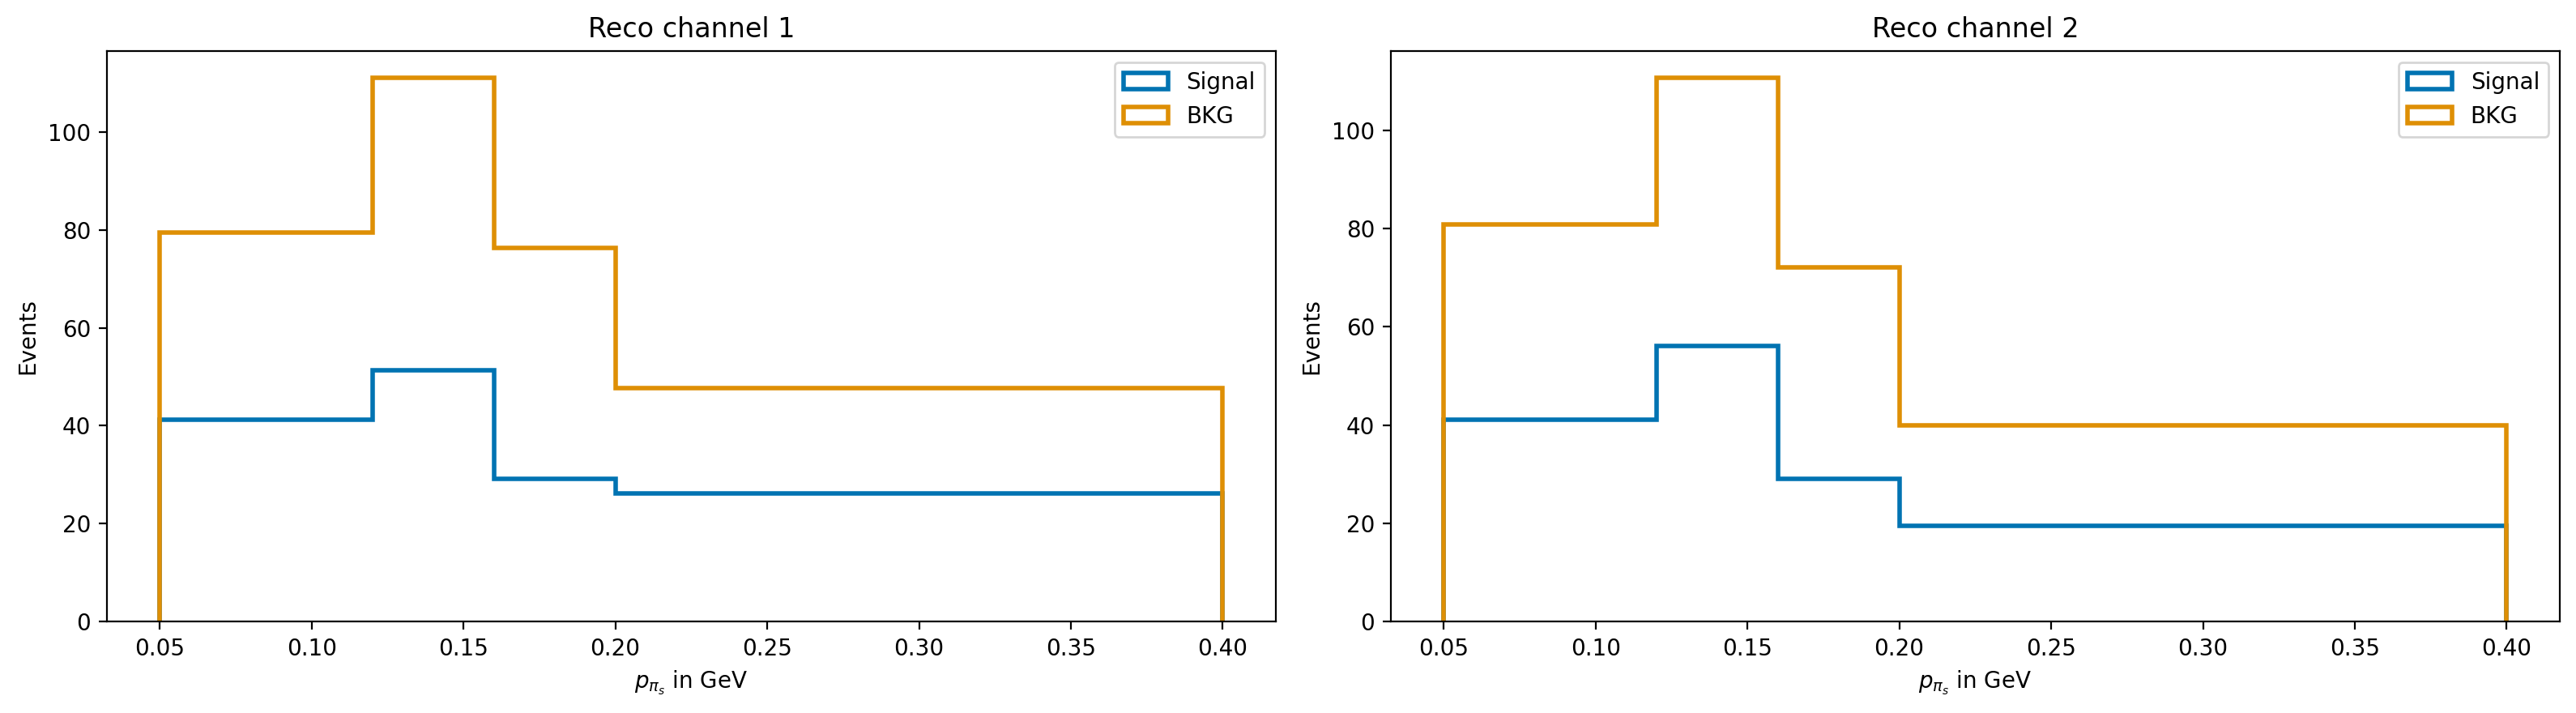

In [6]:
PALETTE = sns.color_palette("colorblind")


def plot_var_in_2_channels(column_name, xlabel, bins, scope):

    fig, ax = plt.subplots(1, 2, figsize = (16, 4.5), dpi = 200)

    for i, c in enumerate(toy_df.channel.value_counts().keys()):
        for j, t in enumerate(toy_df.template.value_counts().keys()):
            tmp_df = toy_df.query(f"channel == {c} & template == '{t}'")
            ax[i].hist(
                tmp_df[column_name],
                weights=tmp_df["total_weight"],
                histtype = "step",
                label = "Signal" if t == "signal" else "BKG",
                bins = bins,
                range = scope,
                linewidth = 2,
                color = PALETTE[j]
            )
        ax[i].legend()
        ax[i].set_xlabel(xlabel)
        ax[i].set_ylabel("Events")
        ax[i].set_title(f"Reco channel {i+1}")


plot_var_in_2_channels("fit_variable1", "Pseudo fit-variable 1", bins = 5, scope = (0,1))
plt.tight_layout()
#plt.savefig("pseudofit1.png", dpi = 200)
plot_var_in_2_channels("fit_variable2", "Pseudo fit-variable 2", bins = 5, scope = (1,4))
plt.tight_layout()
#plt.savefig("pseudofit2.png", dpi = 200)
plot_var_in_2_channels("slow_pi_p", r"$p_{\pi_{s}}$ in GeV", bins = [0.05, 0.12, 0.16, 0.2, 0.4], scope = (0, 0.4))
plt.tight_layout()

# Define the configurations for the Eigen decomposition
(The names in the settings should be revisited and set to sth more meaningful and generic)

In [9]:
from sysvar.utils import read_yaml

settings = read_yaml("study_setup", "MC15ri")
settings

{'output_filepath': './test_output.root',
 'reco_channel_id_column': 'channel',
 'reco_channels': {'channel1': [0], 'channel2': [1]},
 'template_id_column': 'template',
 'templates': ['signal', 'bkg'],
 'total_weight': 'total_weight',
 'MC_prod': 'MC15ri',
 'Nvar': 500,
 'bins': {'channel1': {'fit_variable1': [0, 0.2, 0.4, 0.6, 0.8, 1],
   'fit_variable2': [1, 2, 3, 4]},
  'channel2': {'fit_variable1': [0, 0.2, 0.4, 0.6, 0.8, 1],
   'fit_variable2': [1, 2, 3, 4]}},
 'systematics': {'charged_slow_pi': {'weight': 'charged_weight',
   'prefices': 'slow_pi',
   'reco_channels': {'include': None, 'exclude': None}},
  'neutral_slow_pi': {'weight': 'weight',
   'prefices': 'slow_pi',
   'reco_channels': {'include': None, 'exclude': None}}}}

# First let's save the nominal templates. 
This should always be the first step! It should always be prefered that the nominal histograms are saved before any variations in order to avoid problems with uproot's behavior when saving and updating files

In [10]:
from sysvar import save_nominal_templates
save_nominal_templates(toy_df, settings)

INFO : _create_varied_templates: 227 :  ########## Reco channel: channel1 ##########
INFO : _create_varied_templates: 270 :  Building Template2D for signal
INFO : _create_varied_templates: 270 :  Building Template2D for bkg
INFO : _create_varied_templates: 227 :  ########## Reco channel: channel2 ##########
INFO : _create_varied_templates: 270 :  Building Template2D for signal
INFO : _create_varied_templates: 270 :  Building Template2D for bkg
INFO : save_nominal_templates: 431 :  Recreate file with uproot: ./test_output.root
INFO : save_nominal_templates: 440 :  ##################################################
INFO : save_nominal_templates: 441 :  ########## Reco channel: channel1 ##########
INFO : save_nominal_templates: 442 :  ##################################################
INFO : save_nominal_templates: 445 :  Saving Nominal MC template signal in TBranch: channel1/signal/Nominal
INFO : save_nominal_templates: 445 :  Saving Nominal MC template bkg in TBranch: channel1/bkg/Nomin

# Let's now perform the eigendecomposition. 
The eigendecompose helper function will return an object which is the only input needed to use the rest of the API

In [11]:
from sysvar import eigendecompose

egd = eigendecompose(
    df = toy_df,
    settings = settings,
    syst_effect = "charged_slow_pi",
    #criterion: "max_differences",
    #prec: 0.005,
    #save_variations: False
)

INFO : _create_varied_templates: 227 :  ########## Reco channel: channel1 ##########
INFO : _create_varied_templates: 270 :  Building Template2D for signal
INFO : _create_varied_templates: 270 :  Building Template2D for bkg
INFO : _create_varied_templates: 227 :  ########## Reco channel: channel2 ##########
INFO : _create_varied_templates: 270 :  Building Template2D for signal
INFO : _create_varied_templates: 270 :  Building Template2D for bkg
 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                       | 50/60 [00:00<00:00, 586.78it/s]
INFO : find_important_eigendimension_indices: 338 :  Found that 3 eigendirections matter for 0.0001 per cent precision


# Examine the correlation matrix
The dimensions here are (N_channels * N_templates * Nbins). 

In this case 2x2x15 = 60

In [ ]:
from sysvar import plot_analysis_corr_matrix
plot_analysis_corr_matrix(egd)

# Visualize how many of eigenvariations are important
We will also try to save the figure. This will fail, but have a look at the end of the error message

In [ ]:
from sysvar import plot_cov_diff
plot_cov_diff(egd, save=True, filename = "test_figure")

In [ ]:
from sysvar import register_saving_info

si = {
    "top_dir": "./"
}
register_saving_info(egd, si)

# Now let's try again
Notice that the saving is not failing now, but we are informed that we can more control over the way that the figure are being saved

In [ ]:
plot_cov_diff(egd, save=True, filename = "test_figure")

# Save the templates in the format cabinetry expects
If you did not enable save_variations = True because you were not sure that you want to save the variation you can still do this since you have access to the eigenvariation object.

In [ ]:
# Now save the templates variations throught the EigenDecomposer object
egd.save_template_variations()

Let's examine a bit more closely the templates that we have created

In [ ]:
from sysvar import plot_templates_relative_variations_in_grid, plot_up_and_down_variations
plot_up_and_down_variations(egd)
plot_templates_relative_variations_in_grid(egd)

# Now how did we get those variations ? 

# Every EigenDecomposer object creates a Variator object which implements a covariance matrix between the different correction bins

This ensures that the variations that we sample from are common for every template

In [ ]:
from sysvar import plot_correction_variations_in_grid, plot_correction_cov_and_corr
plot_correction_variations_in_grid(egd)
plot_correction_cov_and_corr(egd)

# What about the corrections itself ? 

In [ ]:
from sysvar import plot_correction_errors
plot_correction_errors(egd)